# 効率性の判定

## 準備

In [55]:
pip install pandas japanize-matplotlib matplotlib seaborn

     ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
     -------------------- ------------------- 2.1/4.1 MB 10.6 MB/s eta 0:00:01
     ----------------------------------- ---- 3.7/4.1 MB 8.6 MB/s eta 0:00:01
     ---------------------------------------- 4.1/4.1 MB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120323 sha256=ea313bb9f854f0c0edf5620d764a02b33a5dedab20b3ddd254c2f3b8244dcea6
  Stored in directory: c:\users\junco\appdata\local\pip\cache\wheels\56\8b\41\7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'japanize-matplotlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'japanize-matplotlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [56]:
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
def add_suffix(pref):
    if isinstance(pref, str):
        if pref in ['東京']:
            return pref + '都'
        elif pref in ['京都','大阪']:
            return pref + '府'
        elif pref.endswith(('道', '府', '県', '都')):
            return pref  # すでに接尾辞あり
        else:
            return pref + '県'  # それ以外には '県' を付ける
    else:
        return pref


## 病院統計：病院の在院患者数と病床数を抽出
def byoin_df(filepass):
    df = pd.read_excel(filepass,sheet_name='参考表10',skiprows=5)
    df = df.drop(columns=['Unnamed: 0','Unnamed: 2'])
    df = df.rename(columns={'Unnamed: 1':'都道府県'})
    df = df.drop(index=[0,1])
    df['都道府県'] = df['都道府県'].apply(add_suffix)
    return df[['都道府県','在院患者\n延数','病床数']]

In [4]:
conda install openpyxl

Channels:
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\junco\anaconda3\envs\healthcare-env

  added / updated specs:
    - openpyxl


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    et_xmlfile-1.1.0           |  py313haa95532_1          13 KB
    openpyxl-3.1.5             |  py313h827c3e9_1         666 KB
    ------------------------------------------------------------
                                           Total:         679 KB

The following NEW packages will be INSTALLED:

  et_xmlfile         pkgs/main/win-64::et_xmlfile-1.1.0-py313haa95532_1 
  openpyxl           pkgs/main/win-64::openpyxl-3.1.5-py313h827c3e9_1 



openpyxl-3.1.5       | 666 KB    |            |   0% 

et_xmlfile-1.1.0     | 13 KB     |            |   0% 

et_xmlfile-1.1.0     | 13 KB     | ########## | 100% 
openpyxl-3

In [5]:
for month in range(1, 13):
    filename = f"24{str(month).zfill(2)}sankou.xlsx"  # 例: 2401sankou.xlsx
    filepath = os.path.join("..", "data", filename)
    globals()[f"df_{month}"] = byoin_df(filepath)

In [6]:
dfs = []

for month in range(1, 13):
    df_month = globals()[f"df_{month}"]
    dfs.append(df_month)

# すべての月を結合
df_all = pd.concat(dfs)

# 最初の月の順番を基準にする（例: df_1 の順序）
pref_order = df_1["都道府県"].tolist()

# カテゴリ型で順序を固定
df_all["都道府県"] = pd.Categorical(df_all["都道府県"], categories=pref_order, ordered=True)

# グループ化して年間合計
df_yearly = df_all.groupby("都道府県", as_index=False).sum()

# 並び順を明示的に反映
df_yearly = df_yearly.sort_values("都道府県")

# 結果確認
df_yearly

C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3698111339.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_yearly = df_all.groupby("都道府県", as_index=False).sum()


,都道府県,在院患者\n延数,病床数
0,北海道,5646066,218636
1,青森県,710921,27711
2,岩手県,559454,23310
3,宮城県,957801,37429
4,秋田県,539703,20820
5,山形県,661688,24564
6,福島県,871459,34954
7,茨城県,1468991,61407
8,栃木県,1121852,44258
9,群馬県,1185730,46166


In [7]:
df_hospital_yearly = df_yearly

In [8]:
## 病院統計：診療所の在院患者数と病床数を抽出１月～３月（４月よりフォーマット変更有）
def shinryo_df_1to3(filepass):
    df = pd.read_excel(filepass,sheet_name='参考表13',skiprows=5)
    df = df.drop(columns=['Unnamed: 0','Unnamed: 2'])
    df = df.rename(columns={'Unnamed: 1':'都道府県'})
    df = df.drop(index=[0,1])
    df = df.replace(['-','.','･'],0)
    df = df.drop(index=[49,50,51])
    df['都道府県'] = df['都道府県'].apply(add_suffix)
    return df[['都道府県','在院患者\n延数']]

In [9]:
for month in range(1, 4):
    filename = f"24{str(month).zfill(2)}sankou.xlsx"  # 例: 2401sankou.xlsx
    filepath = os.path.join("..", "data", filename)
    globals()[f"df_{month}"] = shinryo_df_1to3(filepath)

C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3006588710.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['-','.','･'],0)
C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3006588710.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['-','.','･'],0)
C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3006588710.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

In [10]:
## 病院統計：診療所の在院患者数と病床数を抽出４月～１２月（４月よりフォーマット変更有）
def shinryo_df_4to12(filepass):
    df = pd.read_excel(filepass,sheet_name='参考表12',skiprows=5)
    df = df.drop(columns=['Unnamed: 0','Unnamed: 2'])
    df = df.rename(columns={'Unnamed: 1':'都道府県'})
    df = df.drop(index=[0,1])
    df = df.replace(['-','.','･'],0)
    df = df.drop(index=[49,50,51])
    df['都道府県'] = df['都道府県'].apply(add_suffix)
    return df[['都道府県','在院患者\n延数','病床数']]

In [11]:
for month in range(4, 13):
    filename = f"24{str(month).zfill(2)}sankou.xlsx"  # 例: 2401sankou.xlsx
    filepath = os.path.join("..", "data", filename)
    globals()[f"df_{month}"] = shinryo_df_4to12(filepath)

C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3844865903.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['-','.','･'],0)
C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3844865903.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['-','.','･'],0)
C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3844865903.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

In [12]:
dfs = []

for month in range(1, 13):
    df_month = globals()[f"df_{month}"]
    dfs.append(df_month)

# すべての月を結合
df_all = pd.concat(dfs)

# 最初の月の順番を基準にする（例: df_1 の順序）
pref_order = df_1["都道府県"].tolist()

# カテゴリ型で順序を固定
df_all["都道府県"] = pd.Categorical(df_all["都道府県"], categories=pref_order, ordered=True)
df_all["在院患者\n延数"] = df_all["在院患者\n延数"].astype(int)
# グループ化して年間合計
df_yearly = df_all.groupby("都道府県", as_index=False).sum()

# 並び順を明示的に反映
df_yearly = df_yearly.sort_values("都道府県")
df_yearly['都道府県'] = df_yearly['都道府県'].apply(add_suffix)

# 結果確認
df_yearly

C:\Users\junco\AppData\Local\Temp\ipykernel_19836\1261582951.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_yearly = df_all.groupby("都道府県", as_index=False).sum()


,都道府県,在院患者\n延数,病床数
0,北海道,23150,2092.0
1,青森県,5408,279.0
2,岩手県,195,321.0
3,宮城県,8968,594.0
4,秋田県,6873,279.0
5,山形県,5768,189.0
6,福島県,0,243.0
7,茨城県,9552,466.0
8,栃木県,4029,288.0
9,群馬県,2928,72.0


In [13]:
df_clinic_yearly = df_yearly

In [14]:
##　病院統計：患者数を抽出
def kanja_su(filepass):
    df = pd.read_excel(filepass,sheet_name='参考表２',skiprows=[1,2,3,4,5,6,7,55,56,57])
    df = df.drop(columns=['参考表２　病院の１日平均外来患者数・外来患者延数，病院の種類・都道府県別','Unnamed: 2','Unnamed: 4','Unnamed: 5','Unnamed: 7','Unnamed: 8'])
    df = df.rename(columns={'Unnamed: 1':'都道府県','Unnamed: 3':'１日平均外来患者数（病院）','Unnamed: 6':'外来患者延数（病院）'})
    df['都道府県'] = df['都道府県'].apply(add_suffix)
    return df

In [15]:
for month in range(1, 13):
    filename = f"24{str(month).zfill(2)}sankou.xlsx"  # 例: 2401sankou.xlsx
    filepath = os.path.join("..", "data", filename)
    globals()[f"df_{month}"] = kanja_su(filepath)

In [16]:
dfs = []

for month in range(1, 13):
    df_month = globals()[f"df_{month}"]
    dfs.append(df_month)

# すべての月を結合
df_all = pd.concat(dfs)

# 最初の月の順番を基準にする（例: df_1 の順序）
pref_order = df_1["都道府県"].tolist()

# カテゴリ型で順序を固定
df_all["都道府県"] = pd.Categorical(df_all["都道府県"], categories=pref_order, ordered=True)

# グループ化して年間合計
df_yearly = df_all.groupby("都道府県", as_index=False).sum()

# 並び順を明示的に反映
df_yearly = df_yearly.sort_values("都道府県")

# 結果確認
df_yearly

C:\Users\junco\AppData\Local\Temp\ipykernel_19836\3698111339.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_yearly = df_all.groupby("都道府県", as_index=False).sum()


,都道府県,１日平均外来患者数（病院）,外来患者延数（病院）
0,北海道,794145,24222504
1,青森県,151232,4613079
2,岩手県,132174,4031662
3,宮城県,231114,7049245
4,秋田県,124799,3806876
5,山形県,128637,3923901
6,福島県,211676,6456214
7,茨城県,327753,9996886
8,栃木県,226905,6920315
9,群馬県,218974,6678621


In [17]:
df_patients_yearly = df_yearly

In [18]:
df = df_hospital_yearly

In [19]:
df = df.rename(columns={'在院患者\n延数':'病院在院患者数','病床数':'病院病床数'})

In [20]:
df_clinic = df_clinic_yearly

In [21]:
df_clinic = df_clinic.rename(columns={'在院患者\n延数':'診療所在院患者数','病床数':'診療所病床数'})

In [22]:
df = pd.merge(df,df_clinic,on='都道府県',how='right')

In [23]:
df_patients_yearly = df_patients_yearly.rename(columns={'１日平均外来患者数（病院）':'１日平均外来患者数合計','外来患者延数（病院）':'年間外来患者数'})

In [24]:
df = pd.merge(df,df_patients_yearly,on='都道府県',how='right')

In [25]:
df

,都道府県,病院在院患者数,病院病床数,診療所在院患者数,診療所病床数,１日平均外来患者数合計,年間外来患者数
0,北海道,5646066,218636,23150,2092.0,794145,24222504
1,青森県,710921,27711,5408,279.0,151232,4613079
2,岩手県,559454,23310,195,321.0,132174,4031662
3,宮城県,957801,37429,8968,594.0,231114,7049245
4,秋田県,539703,20820,6873,279.0,124799,3806876
5,山形県,661688,24564,5768,189.0,128637,3923901
6,福島県,871459,34954,0,243.0,211676,6456214
7,茨城県,1468991,61407,9552,466.0,327753,9996886
8,栃木県,1121852,44258,4029,288.0,226905,6920315
9,群馬県,1185730,46166,2928,72.0,218974,6678621


In [26]:
df_ssdse_e= pd.read_csv('../data/ssdse_E_cleaned.csv')

In [27]:
df_ssdse = df_ssdse_e[['都道府県','総人口','医師数','薬剤師数','一般病院数','一般診療所数']]

In [28]:
df_ssdse = df_ssdse.drop(index=[0,1])

In [29]:
df = pd.merge(df_ssdse,df,on='都道府県',how='right')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   都道府県         47 non-null     object 
 1   総人口          47 non-null     object 
 2   医師数          47 non-null     object 
 3   薬剤師数         47 non-null     object 
 4   一般病院数        47 non-null     object 
 5   一般診療所数       47 non-null     object 
 6   病院在院患者数      47 non-null     object 
 7   病院病床数        47 non-null     object 
 8   診療所在院患者数     47 non-null     int64  
 9   診療所病床数       47 non-null     float64
 10  １日平均外来患者数合計  47 non-null     int64  
 11  年間外来患者数      47 non-null     int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ KB


In [31]:
df[['総人口','医師数','薬剤師数','一般病院数','一般診療所数']] = df[['総人口','医師数','薬剤師数','一般病院数','一般診療所数']].astype(int)

In [33]:
print(list(df.columns))

['都道府県', '総人口', '医師数', '薬剤師数', '一般病院数', '一般診療所数', '病院在院患者数', '病院病床数', '診療所在院患者数', '診療所病床数', '１日平均外来患者数合計', '年間外来患者数', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり']


In [36]:
df['在院患者総数'] = df['病院在院患者数'] + df['診療所在院患者数']
df['病床総数'] = df['病院病床数'] + df['診療所病床数']

In [38]:
df['一般病院数_人口10万人あたり'] = df['一般病院数'] / df['総人口'] * 100000
df['医師数_人口10万人あたり'] = df['医師数'] / df['総人口'] * 100000
df['薬剤師数_人口10万人あたり'] = df['薬剤師数'] / df['総人口'] * 100000
df['一般診療所数_人口10万人あたり'] = df['一般診療所数'] / df['総人口'] * 100000
df['病院患者数_人口10万人あたり'] = df['病院在院患者数'] / df['総人口'] * 100000
df['病院病床数_人口10万人あたり'] = df['病院病床数'] / df['総人口'] * 100000
df['診療所患者数_人口10万人あたり'] = df['診療所在院患者数'] / df['総人口'] * 100000
df['診療所病床数_人口10万人あたり'] = df['診療所病床数'] / df['総人口'] * 100000
df['患者総数_人口10万人あたり'] = df['在院患者総数'] / df['総人口'] * 100000
df['病床総数_人口10万人あたり'] = df['病床総数'] / df['総人口'] * 100000
df['１日平均外来患者数合計_人口10万人あたり'] = df['１日平均外来患者数合計'] / df['総人口'] * 100000

In [42]:
pip install scikit-learn

   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   -------- ------------------------------- 2.4/10.7 MB 12.9 MB/s eta 0:00:01
   ---------------- ----------------------- 4.5/10.7 MB 11.2 MB/s eta 0:00:01
   ------------------------ --------------- 6.6/10.7 MB 11.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.9/10.7 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 10.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.4 MB ? eta -:--:--
   - -------------------------------------- 1.8/38.4 MB 9.3 MB/s eta 0:00:04
   ---- ----------------------------------- 3.9/38.4 MB 10.0 MB/s eta 0:00:04
   ------ --------------------------------- 6.6/38.4 MB 11.0 MB/s eta 0:00:03
   --------- ------------------------------ 9.4/38.4 MB 11.7 MB/s eta 0:00:03
   ------------ --------------------------- 11.5/38.4 MB 11.5 MB/s eta 0:00:03
   ------------- -------------------------- 12.6/38.4 MB 10.8 MB/s eta 0:00:03


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [44]:
print(list(df.columns))

['都道府県', '総人口', '医師数', '薬剤師数', '一般病院数', '一般診療所数', '病院在院患者数', '病院病床数', '診療所在院患者数', '診療所病床数', '１日平均外来患者数合計', '年間外来患者数', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '在院患者総数', '病床総数', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり']


In [45]:
df_scaled = scaler.fit_transform(df[['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '在院患者総数', '病床総数', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり']])
df_scaled = pd.DataFrame(df_scaled, columns=['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '在院患者総数', '病床総数', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり'])

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
X = df_scaled[['一般病院数_人口10万人あたり',  '医師数_人口10万人あたり','薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり','病床総数_人口10万人あたり']]

In [49]:
Y = df_scaled['１日平均外来患者数合計_人口10万人あたり']

In [50]:
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
df_coef = pd.DataFrame({'Variables':    X.columns,
                          'Coefficients': model.coef_.reshape(-1,)  #Pythonでは、カッコ内はいくら改行してもOK
                        })
display( df_coef )

print( '切片:',  model.intercept_ )
print( '正解率:', model.score(X,Y) ) 

,Variables,Coefficients
0,一般病院数_人口10万人あたり,0.931360
1,医師数_人口10万人あたり,0.296011
2,薬剤師数_人口10万人あたり,-0.011809
3,一般診療所数_人口10万人あたり,-0.144200
4,病床総数_人口10万人あたり,-0.279610


切片: -1.098814202595812e-16
正解率: 0.7470346800813585


<Axes: >

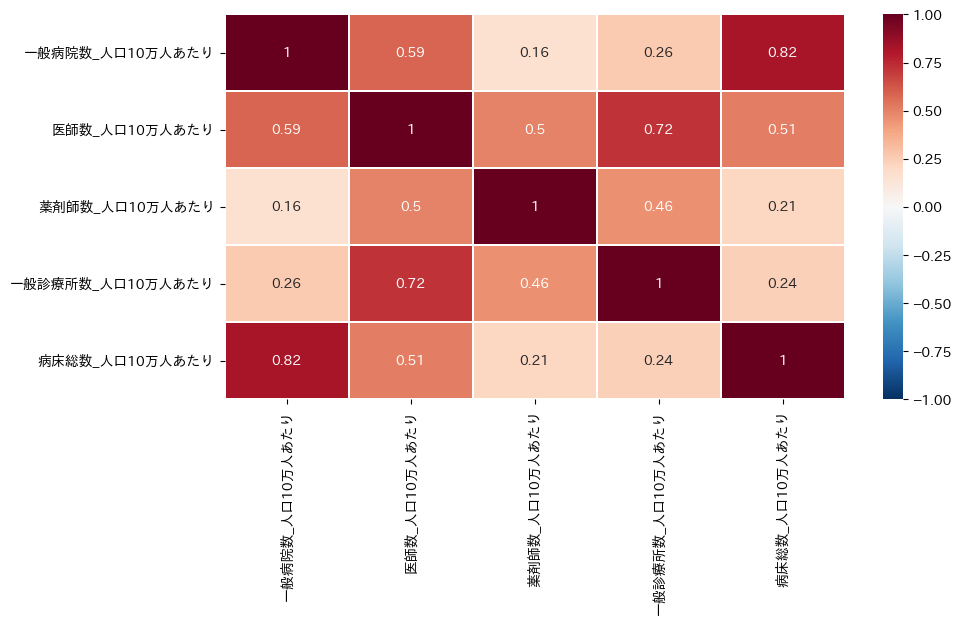

In [57]:
colormap = plt.cm.RdBu_r                 # カラーマップの設定 (RdBu:赤〜青 ⇔ RdBu_r:青〜赤)

plt.rcParams['figure.figsize'] = 10, 5      # Figureサイズの指定

# 相関行列の右上半分を隠したい場合は、次のコメントを解除した上で、sns.heatmap()内に mask=mask という引数を追加
# mask = np.triu(np.ones_like(df.corr(), dtype=bool))

sns.heatmap(X.corr(numeric_only=True),linewidths=0.1, linecolor='white',   # 相関行列df.corr()を引数としヒートマップ作成
            vmax=1.0, vmin=-1.0, cmap=colormap, annot=True)

In [59]:
pip install pyfrontier

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   --- ------------------------------------ 1.3/16.4 MB 7.4 MB/s eta 0:00:03
   ----- ---------------------------------- 2.4/16.4 MB 5.4 MB/s eta 0:00:03
   --------- ------------------------------ 3.9/16.4 MB 6.1 MB/s eta 0:00:03
   ------------ --------------------------- 5.0/16.4 MB 5.9 MB/s eta 0:00:02
   ---------------- ----------------------- 6.8/16.4 MB 6.3 MB/s eta 0:00:02
   --------------------- ------------------ 8.7/16.4 MB 6.8 MB/s eta 0:00:02
   -------------------------- ------------- 10.7/16.4 MB 7.2 MB/s eta 0:00:01
   ------------------------------ --------- 12.3/16.4 MB 7.3 MB/s eta 0:00:01
   ----------------------------------- ---- 14.7/16.4 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 7.7 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [pulp]
   ---------------------------------------- 0/2 [pulp]
   ---------------------------------------- 0

In [60]:
from Pyfrontier.frontier_model import EnvelopDEA 

In [62]:
dea = EnvelopDEA("VRS", "in")
dea.fit(df[['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり',
       '一般診療所数_人口10万人あたり', '病床総数_人口10万人あたり']].to_numpy(),
        df[['１日平均外来患者数合計_人口10万人あたり']].to_numpy())
dea.results

[EnvelopResult(score=1.0, id=0, dmu=DMU(input=array([9.163424124513618, 267.14007782101163, 229.61089494163423,
        66.14785992217898, 4294.31906614786], dtype=object), output=array([15450.29182879]), id=0), weights=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], x_slack=[2.5392139e-11, 1.77902e-10, 2.0121678e-10, 0.0, 1.4910483e-08], y_slack=[-9.9413349e-09]),
 EnvelopResult(score=1.0, id=1, dmu=DMU(input=array([6.312292358803987, 230.3156146179402, 194.7674418604651,
        72.25913621262458, 2324.750830564784], dtype=object), output=array([12560.79734219]), id=1), weights=[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [63]:
scores = [res.score for res in dea.results]
scores_series = pd.Series(scores, name="score")
print(scores_series)

0     1.000000
1     1.000000
2     0.961478
3     1.000000
4     0.984062
5     1.000000
6     0.994886
7     1.000000
8     0.972334
9     0.916465
10    1.000000
11    1.000000
12    0.925427
13    1.000000
14    1.000000
15    0.948883
16    0.912980
17    1.000000
18    0.906590
19    1.000000
20    1.000000
21    0.961925
22    1.000000
23    0.959702
24    1.000000
25    1.000000
26    0.754147
27    0.763407
28    0.911440
29    0.795410
30    0.844013
31    0.914232
32    0.909672
33    0.775633
34    0.803577
35    0.898792
36    1.000000
37    0.918118
38    1.000000
39    0.748358
40    0.819721
41    0.797368
42    0.803923
43    0.966874
44    0.898093
45    0.914041
46    1.000000
Name: score, dtype: float64


In [66]:
df["効率値-in"] = scores_series

In [68]:
df[["都道府県","効率値-in"]]

,都道府県,効率値-in
0,北海道,1.000000
1,青森県,1.000000
2,岩手県,0.961478
3,宮城県,1.000000
4,秋田県,0.984062
5,山形県,1.000000
6,福島県,0.994886
7,茨城県,1.000000
8,栃木県,0.972334
9,群馬県,0.916465


In [69]:
dea = EnvelopDEA("VRS", "out")
dea.fit(df[['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり',
       '一般診療所数_人口10万人あたり', '病床総数_人口10万人あたり']].to_numpy(),
        df[['１日平均外来患者数合計_人口10万人あたり']].to_numpy())
dea.results

[EnvelopResult(score=1.0, id=0, dmu=DMU(input=array([9.163424124513618, 267.14007782101163, 229.61089494163423,
        66.14785992217898, 4294.31906614786], dtype=object), output=array([15450.29182879]), id=0), weights=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], x_slack=[2.5392139e-11, 1.77902e-10, 2.0121678e-10, 0.0, 1.4910483e-08], y_slack=[-9.9413349e-09]),
 EnvelopResult(score=1.0, id=1, dmu=DMU(input=array([6.312292358803987, 230.3156146179402, 194.7674418604651,
        72.25913621262458, 2324.750830564784], dtype=object), output=array([12560.79734219]), id=1), weights=[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [70]:
scores = [res.score for res in dea.results]
scores_series = pd.Series(scores, name="score")
print(scores_series)

0     1.000000
1     1.000000
2     1.115343
3     1.000000
4     1.024219
5     1.000000
6     1.008695
7     1.000000
8     1.050543
9     1.203897
10    1.000000
11    1.000000
12    1.096469
13    1.000000
14    1.000000
15    1.050755
16    1.083717
17    1.000000
18    1.124175
19    1.000000
20    1.000000
21    1.100576
22    1.000000
23    1.114853
24    1.000000
25    1.000000
26    1.266293
27    1.303569
28    1.069157
29    1.144408
30    1.168194
31    1.129821
32    1.044860
33    1.310483
34    1.278386
35    1.025001
36    1.000000
37    1.064538
38    1.000000
39    1.328062
40    1.233253
41    1.219911
42    1.304383
43    1.017426
44    1.170972
45    1.114680
46    1.000000
Name: score, dtype: float64


In [71]:
df["効率値-out"] = scores_series

In [72]:
df[["都道府県","効率値-out"]]

,都道府県,効率値-out
0,北海道,1.000000
1,青森県,1.000000
2,岩手県,1.115343
3,宮城県,1.000000
4,秋田県,1.024219
5,山形県,1.000000
6,福島県,1.008695
7,茨城県,1.000000
8,栃木県,1.050543
9,群馬県,1.203897
